## Phase 1/10 — Data Understanding & Initial Project Setup


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import re

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / 'football_data.csv'

print('Project root:', PROJECT_ROOT)
print('Data path:', DATA_PATH)



Project root: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction
Data path: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\football_data.csv


In [3]:
df_raw = pd.read_csv(DATA_PATH)

print('Dataset loaded successfully')
print('Shape:',df_raw.shape)

display(df_raw.head())

C:\Users\mojta_tok6stl\AppData\Local\Temp\ipykernel_10816\58556683.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(DATA_PATH)


Dataset loaded successfully
Shape: (110938, 190)


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw

In [4]:
def normalize_column_name(column_name):
    
    column_name = str(column_name).strip().lower()
    column_name = re.sub(r"[^\w\s]+",' ',column_name)
    column_name = re.sub(r"\s+",'_',column_name)
    column_name = re.sub(r'_+','_',column_name)
    column_name = column_name.strip('_')
    return column_name


def make_unique_column_names(columns):
    
    seen = {}
    unique_columns = []
    
    for col in columns:
        base = normalize_column_name(col)
        if base not in seen:
            seen[base] = 0
            unique_columns.append(base)
        else:
            seen[base] += 1
            unique_columns.append(f'{base}_{seen[base]}')
            
    return unique_columns


original_columns = list(df_raw.columns)
normalized_columns = make_unique_column_names(original_columns)

column_mapping = pd.DataFrame({
    'original_column': original_columns,
    'normalized_column' : normalized_columns
})

df = df_raw.copy()

df.columns = normalized_columns

print('Column normalization completed')
print('Number of columns :', len(df.columns))

display(column_mapping.head())

Column normalization completed
Number of columns : 190


,original_column,normalized_column
0,match_id,match_id
1,match_result,match_result
2,home_club,home_club
3,away_club,away_club
4,fixture_date,fixture_date


In [5]:
print('dataset Shape')
print('='*60)
print(f'Rows: {df.shape[0]:,}')
print(f'Columns : {df.shape[1]:,}')


print('\nFirst 5 rows')
display(df.head())

print('\nLast 5 rows')
display(df.tail())

print('\nColumn List')
for i,col in enumerate(df.columns,start=1):
        print(f'{i:03d}. {col}')
        

dataset Shape
Rows: 110,938
Columns : 190

First 5 rows


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw


Last 5 rows


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw


Column List
001. match_id
002. match_result
003. home_club
004. away_club
005. fixture_date
006. competition
007. competition_code
008. cup_game
009. home_manager_id
010. away_manager_id
011. home_club_recent_fixture_date_1
012. home_club_recent_fixture_date_2
013. home_club_recent_fixture_date_3
014. home_club_recent_fixture_date_4
015. home_club_recent_fixture_date_5
016. home_club_recent_fixture_date_6
017. home_club_recent_fixture_date_7
018. home_club_recent_fixture_date_8
019. home_club_recent_fixture_date_9
020. home_club_recent_fixture_date_10
021. home_club_recent_played_at_home_1
022. home_club_recent_played_at_home_2
023. home_club_recent_played_at_home_3
024. home_club_recent_played_at_home_4
025. home_club_recent_played_at_home_5
026. home_club_recent_played_at_home_6
027. home_club_recent_played_at_home_7
028. home_club_recent_played_at_home_8
029. home_club_recent_played_at_home_9
030. home_club_recent_played_at_home_10
031. home_club_recent_cup_game_1
032. home_club_re

In [6]:

TARGET_COL = 'match_result'
ID_COL = 'match_id'


MAIN_MATCH_COLUMNS = [
    'match_id',
    'match_result',
    'home_club',
    'away_club',
    'fixture_date',
    'competition',
    'competition_code',
    'cub_game',
    'home_manager_id',
    'away_manager_id'
]



existing_main_columns = [col for col in MAIN_MATCH_COLUMNS if col in df.columns]
missing_main_columns = [col for col in MAIN_MATCH_COLUMNS if col not in df.columns]


main_columns_status = pd.DataFrame({
    'column': MAIN_MATCH_COLUMNS,
    'exists': [col in df.columns for col in MAIN_MATCH_COLUMNS]
})

display(main_columns_status)

if TARGET_COL not in df.columns:
    raise ValueError(
        f'Target column {TARGET_COL} was not found'
        'Please check the dataset column name or update TARGET_COL'
    )
    
print(f'Target column {TARGET_COL} exists')
print(f'Existing main columns: {len(existing_main_columns)}/ {len(MAIN_MATCH_COLUMNS)}')


if missing_main_columns:
    print('WArning : mIssing main columns')
    for col in missing_main_columns:
        print('=',col)

,column,exists
0,match_id,True
1,match_result,True
2,home_club,True
3,away_club,True
4,fixture_date,True
5,competition,True
6,competition_code,True
7,cub_game,False
8,home_manager_id,True
9,away_manager_id,True


Target column match_result exists
Existing main columns: 9/ 10
= cub_game


In [7]:
target_counts = df[TARGET_COL].value_counts(dropna=False)
target_percentages = df[TARGET_COL].value_counts(normalize=True,dropna=False).mul(100)

target_distribution = pd.DataFrame({
    'count': target_counts,
    'percentage' : target_percentages.round(2)
})

print('Target distibution:')
display(target_distribution)

print('Number of target classes:', df[TARGET_COL].nunique(dropna=True))

if df[TARGET_COL].isna().sum()> 0:
    print('warning : Target column contains missing values:', df[TARGET_COL].isna().sum())
    

Target distibution:


,count,percentage
match_result,,
home,48113,43.37
away,35174,31.71
draw,27651,24.92


Number of target classes: 3


In [8]:
dtype_summary = pd.DataFrame({
    'column':df.columns,
    'dtype': df.dtypes.astype(str).values,
    'non_null_count': df.notna().sum().values,
    'null_count': df.isna().sum().values,
    'null_percentage': (df.isna().mean().values *100),
    'unique_count': [df[col].nunique(dropna=True) for col in df.columns]
})

display(dtype_summary.sort_values(['null_percentage','unique_count'],ascending=[False,False]).head(50))

print('Dtype counts :')
display(dtype_summary['dtype'].value_counts().to_frame('count'))

,column,dtype,non_null_count,null_count,null_percentage,unique_count
179,away_club_recent_manager_id_10,float64,83809,27129,24.454200,7936
89,home_club_recent_manager_id_10,float64,84285,26653,24.025131,7891
178,away_club_recent_manager_id_9,float64,84788,26150,23.571725,8044
88,home_club_recent_manager_id_9,float64,85205,25733,23.195839,8002
177,away_club_recent_manager_id_8,float64,85719,25219,22.732517,8144
87,home_club_recent_manager_id_8,float64,86069,24869,22.417026,8150
176,away_club_recent_manager_id_7,float64,86561,24377,21.973535,8303
86,home_club_recent_manager_id_7,float64,86958,23980,21.615677,8265
175,away_club_recent_manager_id_6,float64,87413,23525,21.205538,8440
85,home_club_recent_manager_id_6,float64,87680,23258,20.964863,8385


Dtype counts :


,count
dtype,
float64,162
object,26
int64,2


In [9]:
date_like_columns = [col for col in df.columns if "date" in col]

print("Detected date-like columns:")
for col in date_like_columns:
    print("-", col)

date_parse_report = []

for col in date_like_columns:
    parsed = pd.to_datetime(df[col], errors="coerce")
    success_rate = parsed.notna().mean() * 100

    date_parse_report.append({
        "column": col,
        "original_dtype": str(df[col].dtype),
        "parse_success_percentage": round(success_rate, 2),
        "min_date": parsed.min(),
        "max_date": parsed.max(),
        "null_after_parse": parsed.isna().sum()
    })

date_parse_report = pd.DataFrame(date_parse_report)

display(date_parse_report)


Detected date-like columns:
- fixture_date
- home_club_recent_fixture_date_1
- home_club_recent_fixture_date_2
- home_club_recent_fixture_date_3
- home_club_recent_fixture_date_4
- home_club_recent_fixture_date_5
- home_club_recent_fixture_date_6
- home_club_recent_fixture_date_7
- home_club_recent_fixture_date_8
- home_club_recent_fixture_date_9
- home_club_recent_fixture_date_10
- away_club_recent_fixture_date_1
- away_club_recent_fixture_date_2
- away_club_recent_fixture_date_3
- away_club_recent_fixture_date_4
- away_club_recent_fixture_date_5
- away_club_recent_fixture_date_6
- away_club_recent_fixture_date_7
- away_club_recent_fixture_date_8
- away_club_recent_fixture_date_9
- away_club_recent_fixture_date_10


,column,original_dtype,parse_success_percentage,min_date,max_date,null_after_parse
0,fixture_date,object,100.00,2019-12-01 00:45:00,2021-05-01 00:00:00,0
1,home_club_recent_fixture_date_1,object,98.96,2019-01-04 14:00:00,2021-04-28 23:00:00,1159
2,home_club_recent_fixture_date_2,object,97.79,2019-01-05 02:30:00,2021-04-25 23:00:00,2451
3,home_club_recent_fixture_date_3,object,96.60,2019-01-03 15:45:00,2021-04-23 23:00:00,3773
4,home_club_recent_fixture_date_4,object,95.40,2019-01-03 15:45:00,2021-04-22 00:00:00,5101
5,home_club_recent_fixture_date_5,object,94.16,2019-01-03 15:45:00,2021-04-18 23:00:00,6477
6,home_club_recent_fixture_date_6,object,92.88,2019-01-04 22:30:00,2021-04-17 01:00:00,7896
7,home_club_recent_fixture_date_7,object,91.62,2019-01-02 16:00:00,2021-04-15 00:30:00,9295
8,home_club_recent_fixture_date_8,object,90.34,2019-01-03 23:30:00,2021-04-08 00:30:00,10719
9,home_club_recent_fixture_date_9,object,89.06,2019-01-02 16:00:00,2021-04-03 14:00:00,12136


In [10]:
RECENT_PATTERN = re.compile(r'^(home_club|away_club)_recent_(.+)_(\d+)$')

recent_columns_info = []

for col in df.columns:
    match = RECENT_PATTERN.match(col)
    if match:
        club_side = match.group(1)
        feature_name = match.group(2)
        recent_number = int(match.group(3))
        
        recent_columns_info.append({
            'column':col,
            'club_side':club_side,
            'feature' : feature_name,
            'recent_number': recent_number,
            'dtype': str(df[col].dtype),
            'null_percentage': round(df[col].isna().mean()*100,2),
            'unique_count': df[col].nunique(dropna=True)
        })
        
        
recent_columns_info = pd.DataFrame(recent_columns_info)

print('number of deteceted recent_history columns:',len(recent_columns_info))

if len(recent_columns_info)>0:
    display(recent_columns_info.head(30))
    
    recent_feature_summary= (
        recent_columns_info
        .groupby(['club_side','feature'])
        .agg(
            detected_recent_numbers=('recent_number',lambda x: sorted(list(x))),
            count=('column','count'),
            avg_null_percentage=('null_percentage','mean')
        )
        .reset_index()
    )
    display(recent_feature_summary)
else:
    print('no recent-history columns were detected please check column missing')

number of deteceted recent_history columns: 180


,column,club_side,feature,recent_number,dtype,null_percentage,unique_count
0,home_club_recent_fixture_date_1,home_club,fixture_date,1,object,1.04,19552
1,home_club_recent_fixture_date_2,home_club,fixture_date,2,object,2.21,19543
2,home_club_recent_fixture_date_3,home_club,fixture_date,3,object,3.40,19646
3,home_club_recent_fixture_date_4,home_club,fixture_date,4,object,4.60,19763
4,home_club_recent_fixture_date_5,home_club,fixture_date,5,object,5.84,19850
5,home_club_recent_fixture_date_6,home_club,fixture_date,6,object,7.12,19832
6,home_club_recent_fixture_date_7,home_club,fixture_date,7,object,8.38,19799
7,home_club_recent_fixture_date_8,home_club,fixture_date,8,object,9.66,19764
8,home_club_recent_fixture_date_9,home_club,fixture_date,9,object,10.94,19582
9,home_club_recent_fixture_date_10,home_club,fixture_date,10,object,12.22,19549


,club_side,feature,detected_recent_numbers,count,avg_null_percentage
0,away_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.935
1,away_club,cup_game,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,7.215
2,away_club,fixture_date,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.935
3,away_club,goals_conceded,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.935
4,away_club,goals_scored,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.935
5,away_club,manager_id,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,21.348
6,away_club,opponent_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.945
7,away_club,played_at_home,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.935
8,away_club,team_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.945
9,home_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.541


In [11]:
expected_recent_numbers = set(range(1,11))

recent_structure_checks = []

if len(recent_columns_info) > 0:
    for (club_side,feature),group in recent_columns_info.groupby(['club_side','feature']):
        deteceted_numbers = set(group['recent_number'].tolist())
        missing_number = sorted(list(expected_recent_numbers-deteceted_numbers))
        extra_numbers = sorted(list(deteceted_numbers-expected_recent_numbers))
        
        recent_structure_checks.append({
            'club_side':club_side,
            'feature':feature,
            'deteceted_count': len(deteceted_numbers),
            'missing_numbers': missing_number,
            'extra_numbers': extra_numbers,
            'is_complete_1_to_10':len(missing_number) == 0 and len(extra_numbers) == 0
        })
        
        
recent_structure_checks = pd.DataFrame(recent_structure_checks)

display(recent_structure_checks)

if len(recent_structure_checks) > 0:
    incomplete_recent_features = recent_structure_checks[~recent_structure_checks['is_complete_1_to_10']]
    
    if len(incomplete_recent_features) == 0:
        print('all detected recent-history features have numbers 1 to 10')
    else:
        print('warning some recent-history features are incomplete')
        display(incomplete_recent_features)

,club_side,feature,deteceted_count,missing_numbers,extra_numbers,is_complete_1_to_10
0,away_club,competition_code,10,[],[],True
1,away_club,cup_game,10,[],[],True
2,away_club,fixture_date,10,[],[],True
3,away_club,goals_conceded,10,[],[],True
4,away_club,goals_scored,10,[],[],True
5,away_club,manager_id,10,[],[],True
6,away_club,opponent_rating,10,[],[],True
7,away_club,played_at_home,10,[],[],True
8,away_club,team_rating,10,[],[],True
9,home_club,competition_code,10,[],[],True


all detected recent-history features have numbers 1 to 10


In [12]:
full_duplicate_count = df.duplicated().sum()
print('full duplicated rows:' , full_duplicate_count)

if ID_COL in df.columns:
    duplicated_match_id_count = df[ID_COL].duplicated().sum()
    print('duplicated match_id values',duplicated_match_id_count)
    
    if duplicated_match_id_count > 0:
        duplicated_ids_preview = df[df[ID_COL].duplicated(keep=False)].sort_values(ID_COL).head(20)
        display(duplicated_ids_preview)
else:
    print(f'Column {ID_COL} not found skipping match_id duplicate check')

full duplicated rows: 0
duplicated match_id values 0


In [13]:

missing_summary = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isna().sum().values,
    'missing_percentage' : (df.isna().mean().values*100).round(2),
    'dtype': df.dtypes.astype(str).values
})

missing_summary = missing_summary.sort_values('missing_percentage',ascending=False)

print('Top columns by missing percentage: ')
display(missing_summary.head(50))

columns_with_missing = missing_summary[missing_summary['missing_count']>0]

print(f' Columns with at least one missing value : {len(columns_with_missing)}/ {df.shape[1]}')


Top columns by missing percentage: 


,column,missing_count,missing_percentage,dtype
179,away_club_recent_manager_id_10,27129,24.45,float64
89,home_club_recent_manager_id_10,26653,24.03,float64
178,away_club_recent_manager_id_9,26150,23.57,float64
88,home_club_recent_manager_id_9,25733,23.20,float64
177,away_club_recent_manager_id_8,25219,22.73,float64
87,home_club_recent_manager_id_8,24869,22.42,float64
176,away_club_recent_manager_id_7,24377,21.97,float64
86,home_club_recent_manager_id_7,23980,21.62,float64
175,away_club_recent_manager_id_6,23525,21.21,float64
85,home_club_recent_manager_id_6,23258,20.96,float64


 Columns with at least one missing value : 186/ 190


In [14]:

possible_categorical_columns = [
    col for col in df.columns
    if(
        df[col].dtype == 'object'
        or 'club' in col
        or 'competition' in col
        or 'manager' in col
        or 'result' in col
    )
]


categorical_cardinality = pd.DataFrame({
    'column': possible_categorical_columns,
    'dtype': [str(df[col].dtype) for col in possible_categorical_columns],
    'unique_count': [df[col].nunique(dropna=True) for col in possible_categorical_columns],
    'missing_percentage': [round(df[col].isna().mean()*100,2) for col in possible_categorical_columns]
}).sort_values('unique_count',ascending=False)

display(categorical_cardinality.head(50))

,column,dtype,unique_count,missing_percentage
69,home_club_recent_opponent_rating_1,float64,103250,1.06
149,away_club_recent_team_rating_1,float64,103200,1.12
59,home_club_recent_team_rating_1,float64,103169,1.06
159,away_club_recent_opponent_rating_1,float64,103089,1.12
60,home_club_recent_team_rating_2,float64,101900,2.22
70,home_club_recent_opponent_rating_2,float64,101841,2.22
160,away_club_recent_opponent_rating_2,float64,101786,2.35
150,away_club_recent_team_rating_2,float64,101757,2.35
61,home_club_recent_team_rating_3,float64,100658,3.41
71,home_club_recent_opponent_rating_3,float64,100641,3.41


In [15]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

print('number of numeric columns:',len(numeric_columns))

if numeric_columns:
    numeric_description = df[numeric_columns].describe().T
    numeric_description['missing_percentage'] = df[numeric_columns].isna().mean().mul(100).round(2)
    display(numeric_description.head(50))
    
else:
    print('no numeric columns detected')

number of numeric columns: 164


,count,mean,std,min,25%,50%,75%,max,missing_percentage
match_id,110938.0,1.519875e+07,2.536393e+06,1.142829e+07,1.200038e+07,1.675988e+07,1.724230e+07,1.805384e+07,0.00
competition_code,110938.0,9.104570e+02,5.491210e+02,2.000000e+00,4.440000e+02,9.470000e+02,1.293000e+03,2.039000e+03,0.00
home_manager_id,89217.0,1.287134e+07,1.578479e+07,2.000000e+00,4.596120e+05,1.552728e+06,3.243116e+07,3.756849e+07,19.58
away_manager_id,89123.0,1.291552e+07,1.580344e+07,2.000000e+00,4.595650e+05,1.552806e+06,3.279539e+07,3.756847e+07,19.66
home_club_recent_played_at_home_1,109779.0,3.069440e-01,4.612280e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.04
home_club_recent_played_at_home_2,108487.0,5.678008e-01,4.953840e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.21
home_club_recent_played_at_home_3,107165.0,4.661410e-01,4.988546e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,3.40
home_club_recent_played_at_home_4,105837.0,5.194686e-01,4.996232e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.60
home_club_recent_played_at_home_5,104461.0,4.878567e-01,4.998549e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,5.84
home_club_recent_played_at_home_6,103042.0,5.072883e-01,4.999493e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,7.12


In [16]:

leakage_suspicious_keywords =[
    'result',
    'final',
    'score',
    'winner',
    'outcome',
    'home_goals',
    'away_goals',
    'full_time',
    'half_time'
]
suspicious_columns = []

for col in df.columns:
    col_lower = col.lower()
    if col == TARGET_COL:
        continue
    if any(keyword in col_lower for keyword in leakage_suspicious_keywords):
        suspicious_columns.append(col)
        
print('Potentially suspicious columns for leakage: ')

if suspicious_columns:
    for col in suspicious_columns:
        print('=',col)
else:
    print('no obvious suspicious leakage columns detected based on keyword')
    
print('\nImportant')
print('this is only a keword-based warning . Final leakage validation must be done before modeling')

Potentially suspicious columns for leakage: 
= home_club_recent_goals_scored_1
= home_club_recent_goals_scored_2
= home_club_recent_goals_scored_3
= home_club_recent_goals_scored_4
= home_club_recent_goals_scored_5
= home_club_recent_goals_scored_6
= home_club_recent_goals_scored_7
= home_club_recent_goals_scored_8
= home_club_recent_goals_scored_9
= home_club_recent_goals_scored_10
= away_club_recent_goals_scored_1
= away_club_recent_goals_scored_2
= away_club_recent_goals_scored_3
= away_club_recent_goals_scored_4
= away_club_recent_goals_scored_5
= away_club_recent_goals_scored_6
= away_club_recent_goals_scored_7
= away_club_recent_goals_scored_8
= away_club_recent_goals_scored_9
= away_club_recent_goals_scored_10

Important
this is only a keword-based warning . Final leakage validation must be done before modeling


In [17]:

import json


phase_1_summary ={
    'dataset_path' : str(DATA_PATH),
    'n_rows': int(df.shape[0]),
    'n_columns':int(df.shape[1]),
    'target_column':TARGET_COL,
    'target_exists' : TARGET_COL in df.columns,
    'id_column': ID_COL,
    'id_exists': ID_COL in df.columns,
    'main_columns_existing': existing_main_columns,
    'main_columns_missing':missing_main_columns,
    'n_target_classes': int(df[TARGET_COL].nunique(dropna=True)),
    'target_missing_count': int(df[TARGET_COL].isna().sum()),
    'full_duplicate_rows': int(len(columns_with_missing)),
    'columns_with_missing_count' : int(len(columns_with_missing)),
    'recent_history_columns_detected': int(len(recent_columns_info)),
    'date_like_columns_detected': date_like_columns,
    'suspicious_leakage_columns' : suspicious_columns
}


print(json.dumps(phase_1_summary,indent=4,ensure_ascii=False,default=str))

{
    "dataset_path": "c:\\Users\\mojta_tok6stl\\OneDrive\\Desktop\\learning_ai\\Football_Match_Prediction\\football_data.csv",
    "n_rows": 110938,
    "n_columns": 190,
    "target_column": "match_result",
    "target_exists": true,
    "id_column": "match_id",
    "id_exists": true,
    "main_columns_existing": [
        "match_id",
        "match_result",
        "home_club",
        "away_club",
        "fixture_date",
        "competition",
        "competition_code",
        "home_manager_id",
        "away_manager_id"
    ],
    "main_columns_missing": [
        "cub_game"
    ],
    "n_target_classes": 3,
    "target_missing_count": 0,
    "full_duplicate_rows": 186,
    "columns_with_missing_count": 186,
    "recent_history_columns_detected": 180,
    "date_like_columns_detected": [
        "fixture_date",
        "home_club_recent_fixture_date_1",
        "home_club_recent_fixture_date_2",
        "home_club_recent_fixture_date_3",
        "home_club_recent_fixture_date_4",

In [18]:
phase_1_report_dir = PROJECT_ROOT / "phase_1_data_understanding"
phase_1_report_dir.mkdir(parents=True, exist_ok=True)

column_mapping.to_csv(phase_1_report_dir / "column_mapping.csv", index=False)
dtype_summary.to_csv(phase_1_report_dir / "dtype_summary.csv", index=False)
missing_summary.to_csv(phase_1_report_dir / "missing_summary.csv", index=False)

if len(recent_columns_info) > 0:
    recent_columns_info.to_csv(
        phase_1_report_dir / "recent_columns_info.csv",
        index=False
    )

if "recent_structure_checks" in globals() and len(recent_structure_checks) > 0:
    recent_structure_checks.to_csv(
        phase_1_report_dir / "recent_structure_checks.csv",
        index=False
    )

with open(phase_1_report_dir / "phase_1_summary.json", "w", encoding="utf-8") as f:
    json.dump(
        phase_1_summary,
        f,
        indent=4,
        ensure_ascii=False,
        default=str
    )

print("Phase 1 reports saved to:")
print(phase_1_report_dir)

Phase 1 reports saved to:
c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\phase_1_data_understanding


## Phase 2/10 — Exploratory Data Analysis / EDA


In [19]:
import matplotlib.pyplot as plt
from IPython.display import display

print('*'*70)
print('Phase 2: EDA')
print('*'*70)


if 'df' not in globals():
    raise RuntimeError(
        'df is not defined please run Phase 1 first'
    )
    
df_eda = df.copy()

print('Dataset is ready for eda')
print('Shape:', df_eda.shape)

display(df_eda.head())

**********************************************************************
Phase 2: EDA
**********************************************************************
Dataset is ready for eda
Shape: (110938, 190)


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw

In [20]:
TARGET_COL = 'match_result'
ID_COL = 'match_id'


MAIN_MATCH_COLUMNS  = [
    'match_id',
    'match_result',
    'home_club',
    'away_club',
    'fixture_date',
    'competition',
    'competition_code',
    'cup_game',
    'home_manager_id',
    'away_manager_id'
]


PHASE_2_REPORT_DIR = PROJECT_ROOT / 'reports' / 'phase_2_eda'
PHASE_2_FIGURES_DIR  = PHASE_2_REPORT_DIR / 'figure'

PHASE_2_REPORT_DIR.mkdir(parents=True,exist_ok = True)
PHASE_2_FIGURES_DIR.mkdir(parents=True,exist_ok= True)


if TARGET_COL not in df.columns:
    raise ValueError(f'Target column {TARGET_COL} not found check names from phase 1')

print('Target columns:',TARGET_COL) 
print('Reports will be saved to : ', PHASE_2_REPORT_DIR)
print('Figures will be saved to : ', PHASE_2_FIGURES_DIR)


Target columns: match_result
Reports will be saved to :  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda
Figures will be saved to :  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figure


In [21]:

def save_current_figure(filename,dpi=150):
    path = PHASE_2_FIGURES_DIR /filename
    plt.tight_layout()
    plt.savefig(path,dpi=dpi,bbox_inches='tight')
    print('Saved figure: ',path)
    
    
def existing_column(columns,dataframe=df):
    return [col for col in columns if col not in dataframe.columns]


def missing_columns(columns,dataframe=df):
    return [col for col in columns if col not in dataframe.columns]

def plot_bar(series,title,xlabel='',ylabel='Count',filename=None,rotation=45,figsize=(10,5)):
    if series is None or len(series) == 0:
        print('Nothing to plot')
        return
    
    
    plt.figure(figsize=figsize)
    plt.bar(series.index.astype(str),series.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation,ha='right')
    plt.grid(axis='y',alpha=0.3)
    
    if filename:
        save_current_figure(filename)
        
    plt.show()
    
    
def plot_line(series,title,xlabel='',ylabel='',filename=None,figsize=(10,5)):
    if series is None or len(series) == 0:
        print('NOthing to plot')
        
        return
    
    
    plt.figure(figsize=figsize)
    plt.plot(series.index,series.values,marker='o')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    
    if filename:
        save_current_figure(filename)
        
    
    plt.show()
    
    

def plot_grouped_bar(dataframe,title,xlabel='',ylabel='',filename=None,rotation=45,figsize=(12,5)):
    if dataframe is None or dataframe.empty:
        print('Nothing to plot')
        return
    
    
    ax = dataframe.plot(kind='bar',figsize=figsize)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rotation,ha='right')
    plt.grid(axis='y',alpha=0.3)
    plt.legend(title='Class',bbox_to_anchor=(1.02,1),loc='upper left')
    
    
    if filename:
        save_current_figure(filename)
        
    plt.show()
    

def plot_stacked_percentage(dataframe,title,xlabel='',ylabel='Percentage',filename=None,rotation=45,figsize=(12,5)):
    if dataframe is None or dataframe.empty:
        print('Nothing to plot')
        return
    
    
    
    ax = dataframe.plot(kind='bar',stacked=True,figsize=figsize)
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rotation,ha='right')
    plt.grid(axis='y',alpha=0.3)
    plt.legend(title='Match result',bbox_to_anchor=(1.02,1),loc='upper left')
    
    if filename:
        save_current_figure(filename)
        
    plt.show()
    
    
def to_numeric_series(series):
    return pd.to_numeric(series,errors='coerce')


def get_recent_columns(side,feature,numbers=range(1,11),dataframe=df):
    cols=[]
    
    
    
    for number in numbers:
        col = f'{side}-recent-{feature}-{number}'
        if col in dataframe.columns:
            col.append(col)
            
    return cols



def recent_pattern_info(dataframe=df):
    pattern = re.compile(r'^(home_club|away_club)_recent(.+)_(\d+)$')
    rows = []
    
    
    for col in dataframe.columns:
        match = pattern.match(col)
        
        
        if match:
            rows.append({
                'column':col,
                'club_side':match.group(1),
                'feature':match.group(2),
                'recent_number':int(match.group(3)),
                'dtype': str(dataframe[col].dtype),
                'missing_count': int(dataframe[col].isna().sum()),
                'missing_percentage': round(dataframe[col].isna().mean()*100,2),
                'unique_count': int(dataframe[col].nunique(dropna=True))
            })
            
    return pd.DataFrame(rows)




def crosstab_percentage(dataframe,row_col,target_col=TARGET_COL):
    table = pd.crosstab(dataframe[row_col],dataframe[target_col],normalize='index')
    table = table.mul(100).round(2)
    return table


def target_distribution_by_group(dataframe,group_col,min_count=30,target_col=TARGET_COL):
    group_counts = dataframe[group_col].value_counts(dropna=False)
    valid_groups = group_counts[group_counts >= min_count].index
    
    temp = dataframe[dataframe[group_col].isin(valid_groups)].copy()
    
    
    if temp.empty:
        return pd.DataFrame()
    
    table = pd.crosstab(temp[group_col],temp[target_col],normalize='index').mul(100).round(2)
    table['row_count'] = temp[group_col].value_counts(dropna=False).reindex(table.index)
    
    table = table.sort_values('row_count',ascending=False)
    
    return table

def safe_save_csv(dataframe,filename,index=False):
    path = PHASE_2_REPORT_DIR /filename
    dataframe.to_csv(path,index=index)
    print('Saved:',path)
    

In [22]:


main_columns_status = pd.DataFrame({
    'column': MAIN_MATCH_COLUMNS,
    'exists': [col in df.columns for col in MAIN_MATCH_COLUMNS],
    'dtype' : [str(df[col].dtype) if col in df.columns else None for col in MAIN_MATCH_COLUMNS],
    'missing_percentage': [
        round(df[col].isna().mean()*100,2) if col in df.columns else None
        for col in MAIN_MATCH_COLUMNS
    ],
    'unique_count':[
        df[col].nunique(dropna=True) if col in  df.columns else None
        for col in MAIN_MATCH_COLUMNS
    ]
})

display(main_columns_status)
safe_save_csv(main_columns_status,'main_columns_status.csv',index=False)


missing_main_cols = missing_columns(MAIN_MATCH_COLUMNS)

if missing_main_columns:
    print('Warning:  missing mian columns: ')
    for col in missing_main_columns:
        print('=',col)
else:
    print('all main match columns are available')

,column,exists,dtype,missing_percentage,unique_count
0,match_id,True,int64,0.00,110938
1,match_result,True,object,0.00,3
2,home_club,True,object,0.00,9813
3,away_club,True,object,0.00,9892
4,fixture_date,True,object,0.00,20269
5,competition,True,object,0.00,727
6,competition_code,True,int64,0.00,862
7,cup_game,True,object,0.00,2
8,home_manager_id,True,float64,19.58,8804
9,away_manager_id,True,float64,19.66,8938


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\main_columns_status.csv
= cub_game


,count,percentage
match_result,,
home,48113,43.37
away,35174,31.71
draw,27651,24.92


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\target_distribution.csv
Saved figure:  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figure\01_match_result_distribution.png


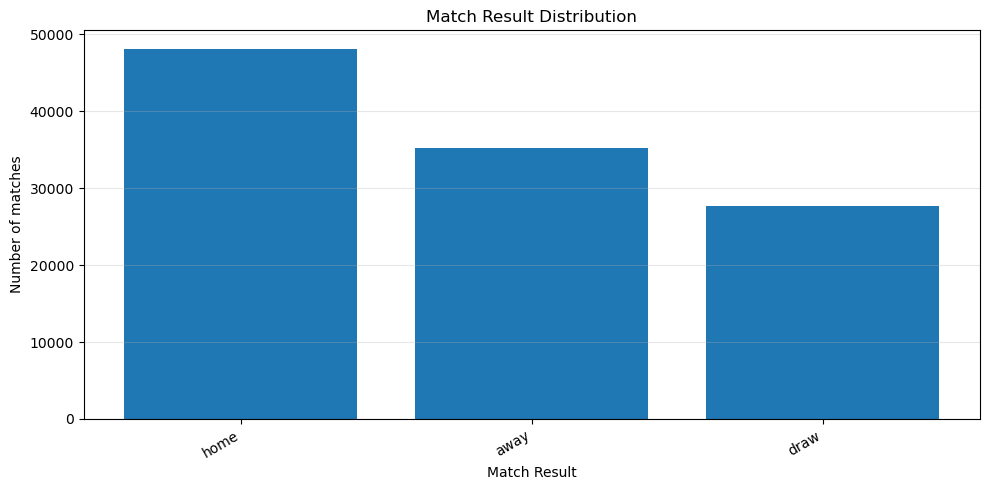

Majority class:  home
Majority baseline accuracy:  0.4337


{'majority_class': 'home',
 'majority_baseline_accuracy': 0.4336926932160306,
 'number_of_classes': 3,
 'target_missing_count': 0}

In [23]:
target_counts = df[TARGET_COL].value_counts(dropna=False)
target_percentages = df[TARGET_COL].value_counts(normalize=True,dropna=False).mul(100).round(2)


target_distribution = pd.DataFrame({
    'count': target_counts,
    'percentage': target_percentages
})

display(target_distribution)

safe_save_csv(target_distribution.reset_index().rename(columns={'index':TARGET_COL}),'target_distribution.csv',index=False)

plot_bar(
    target_distribution['count'],
    title = 'Match Result Distribution',
    xlabel='Match Result',
    ylabel='Number of matches',
    filename= '01_match_result_distribution.png',
    rotation=30
)

majority_class = target_counts.idxmax()
majority_baseline_accuracy = target_counts.max() / len(df)


print('Majority class: ', majority_class)
print(f'Majority baseline accuracy: {majority_baseline_accuracy: .4f}')

class_balance_report = {
    'majority_class' : str(majority_class),
    'majority_baseline_accuracy': float(majority_baseline_accuracy),
    'number_of_classes': int(df[TARGET_COL].nunique(dropna=True)),
    'target_missing_count': int(df[TARGET_COL].isna().sum())
}

class_balance_report

Fixture date parse success: 100.00
Minimum fixture date: 2019-12-01 00:45:00
Maximum fixture date: 2021-05-01 00:00:00


,matches_count
fixture_year,
2019,6105
2020,71588
2021,33245


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\yearly_match_counts.csv
Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\monthly_match_counts.csv
Saved figure:  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figure\02_matches_by_year.png


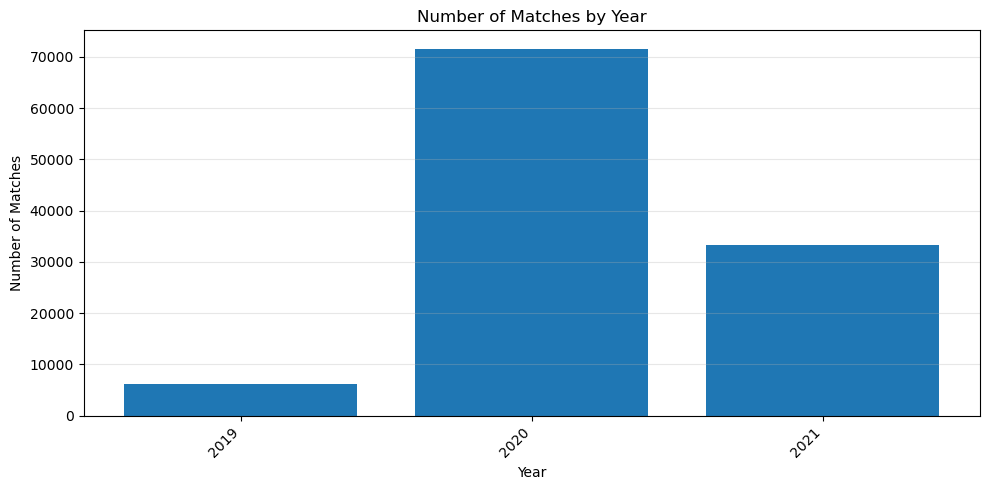

Saved figure:  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figure\03_matches_by_month.png


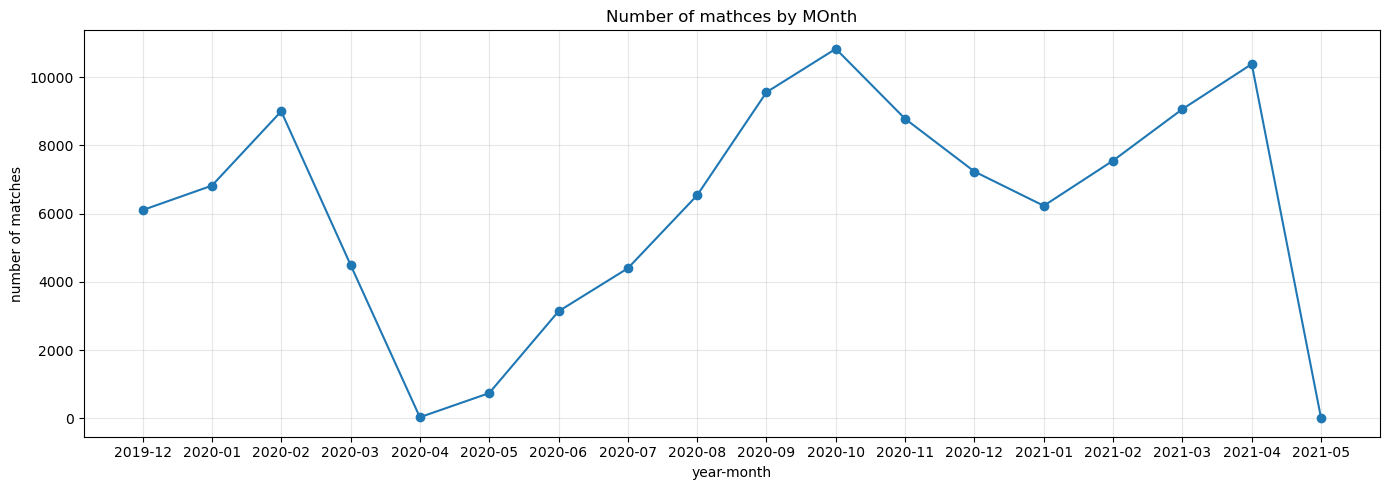

In [24]:
eda_df = df.copy()

if 'fixture_date' in eda_df.columns:
    eda_df['fixture_date_parsed'] = pd.to_datetime(eda_df['fixture_date'],errors='coerce')
    
    date_parse_success = eda_df['fixture_date_parsed'].notna().mean()*100
    
    print(f'Fixture date parse success: {date_parse_success:.2f}')
    print('Minimum fixture date:',eda_df['fixture_date_parsed'].min())
    print('Maximum fixture date:',eda_df['fixture_date_parsed'].max())
    
    
    eda_df['fixture_year'] = eda_df['fixture_date_parsed'].dt.year
    eda_df['fixture_month'] = eda_df['fixture_date_parsed'].dt.month
    eda_df['fixture_year_month']= eda_df['fixture_date_parsed'].dt.to_period('M').astype(str)
    
    yearly_match_counts = eda_df['fixture_year'].value_counts().sort_index()
    monthly_match_counts = eda_df['fixture_year_month'].value_counts().sort_index()
    
    
    display(pd.DataFrame({'matches_count':yearly_match_counts}))
    
    
    safe_save_csv(
        yearly_match_counts.reset_index().rename(columns={'index':'year','fixture_year':'matches_count'}),
        'yearly_match_counts.csv',
        index=False,
    )
    
    safe_save_csv(
        monthly_match_counts.reset_index().rename(columns={'index':'year_month','fixture_year_month':'matches_count'}),
        'monthly_match_counts.csv',
        index=False
    )
    
    
    plot_bar(
        yearly_match_counts,
        title='Number of Matches by Year',
        xlabel='Year',
        ylabel= 'Number of Matches',
        filename='02_matches_by_year.png',
        rotation= 45
    )
    
    
    if len(monthly_match_counts) <= 80:
        plot_line(
                monthly_match_counts,
                title='Number of mathces by MOnth',
                xlabel='year-month',
                ylabel='number of matches',
                filename= '03_matches_by_month.png',
                figsize=(14,5)
        )
else:
    print('fixture_date column does not exist. skip date analysis')

,matches_count,percentage
competition,,
Premier League,5565,5.02
Club Friendlies,3724,3.36
Primera Division,2369,2.14
Super League,1530,1.38
3. Liga,1327,1.20
Ligue 1,1210,1.09
Championship,1097,0.99
League One,1050,0.95
Superliga,1048,0.94


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\competition_counts.csv
Saved figure:  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figure\04_top_competitions.png


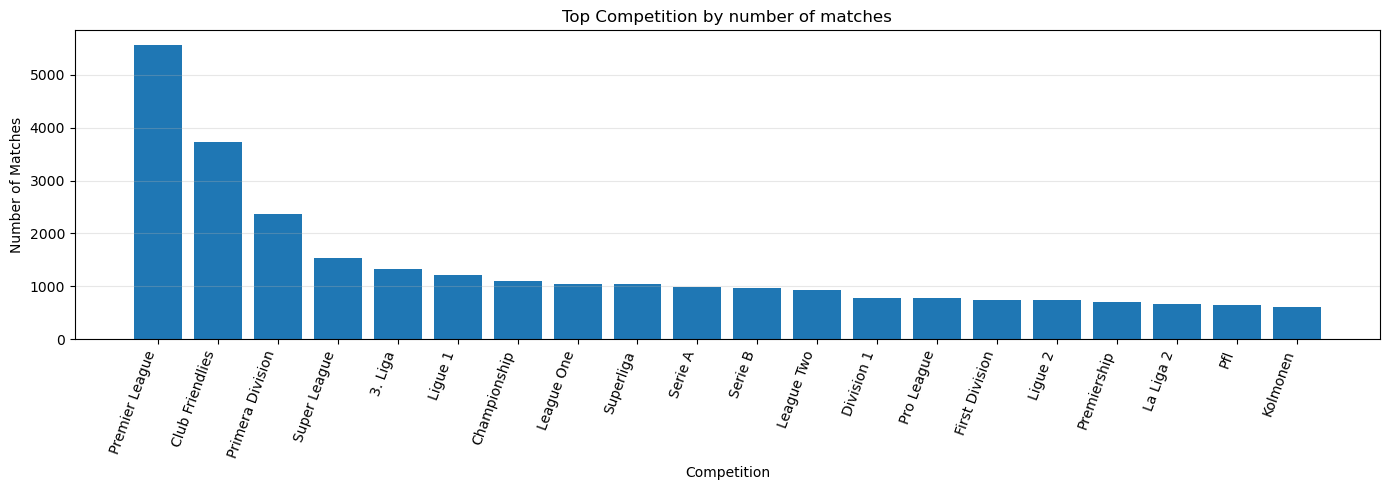

match_result,away,draw,home,row_count
competition,,,,
Premier League,32.94,26.59,40.47,5565
Club Friendlies,31.23,22.72,46.05,3724
Primera Division,27.73,29.59,42.68,2369
Super League,28.63,28.56,42.81,1530
3. Liga,33.84,24.49,41.67,1327
Ligue 1,29.42,29.67,40.91,1210
Championship,33.55,26.34,40.11,1097
League One,31.81,25.90,42.29,1050
Superliga,31.87,25.76,42.37,1048


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\competition_target_distribution.csv
Saved figure:  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figure\05_target_distribution_by_competition.png


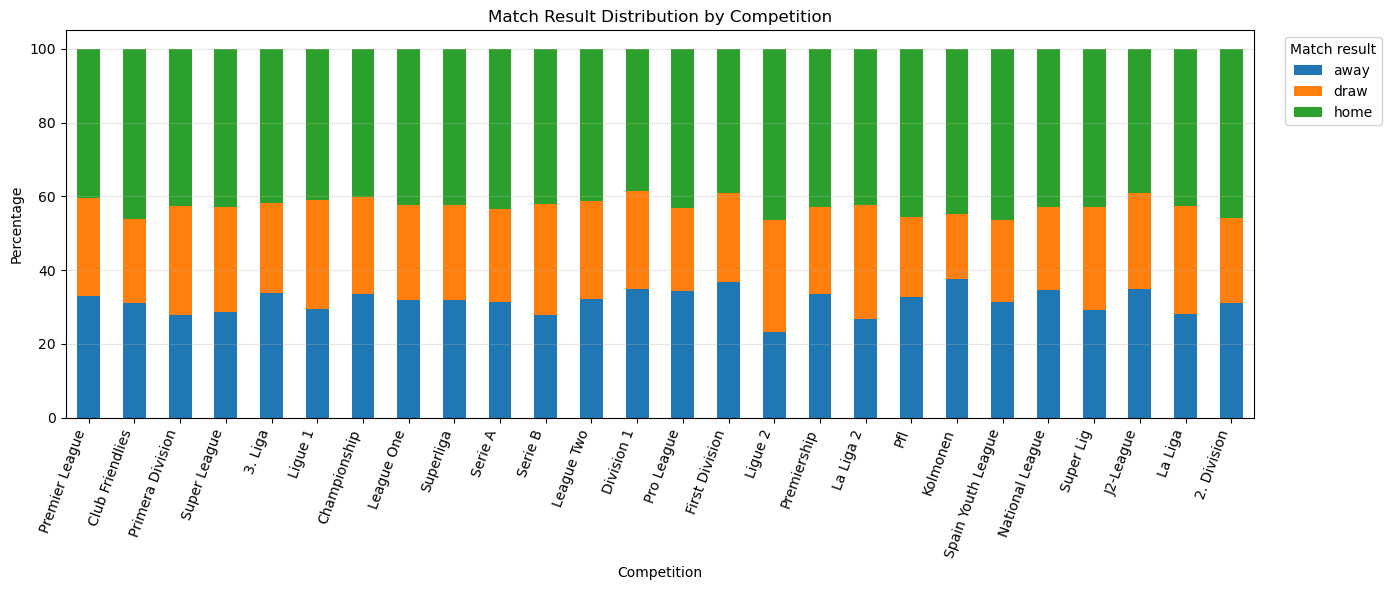

In [25]:

if 'competition' in eda_df.columns:
    competition_counts = eda_df['competition'].value_counts(dropna=False)
    top_competitions = competition_counts.head(20)
    
    
    display(pd.DataFrame({
        'matches_count': competition_counts,
        'percentage' : eda_df['competition'].value_counts(normalize=True,dropna=False).mul(100).round(2)
    }).head(30))
    
    
    
    safe_save_csv(
        competition_counts.reset_index().rename(columns={'index':'competiton','competition':'match_count'}),
        'competition_counts.csv',
        index=False
    )
    
    plot_bar(
        top_competitions,
        title='Top Competition by number of matches',
        xlabel='Competition',
        ylabel= 'Number of Matches',
        filename= '04_top_competitions.png',
        rotation= 70,
        figsize=(14,5)
    )
    
    min_competition_count = max(20,int(len(eda_df)*0.005))
    
    competition_target_distribution = target_distribution_by_group(
        eda_df,
        group_col='competition',
        min_count = min_competition_count,
        target_col = TARGET_COL
    )
    
    
    display(competition_target_distribution.head(30))
    
    safe_save_csv(competition_target_distribution.reset_index(),'competition_target_distribution.csv',index=False)
    
    
    
    if not competition_target_distribution.empty:
        plot_stacked_percentage(
            competition_target_distribution.drop(columns=['row_count']).head(30),
            title='Match Result Distribution by Competition',
            xlabel='Competition',
            filename= '05_target_distribution_by_competition.png',
            rotation=70,
            figsize=(14,6)
        )
    
    
    
else:
    print('competition column does not exist skip competition analysis')

,count,percentage
cup_game,,
False,101856,91.81
True,9081,8.19
NaN,1,0.00


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\cup_game_distribution.csv


match_result,away,draw,home
cup_game,,,
False,31.35,25.24,43.41
True,35.70,21.41,42.89


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\cup_game_target_distribution.csv
Saved figure:  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figure\06_target_distribution_by_cup_game.png


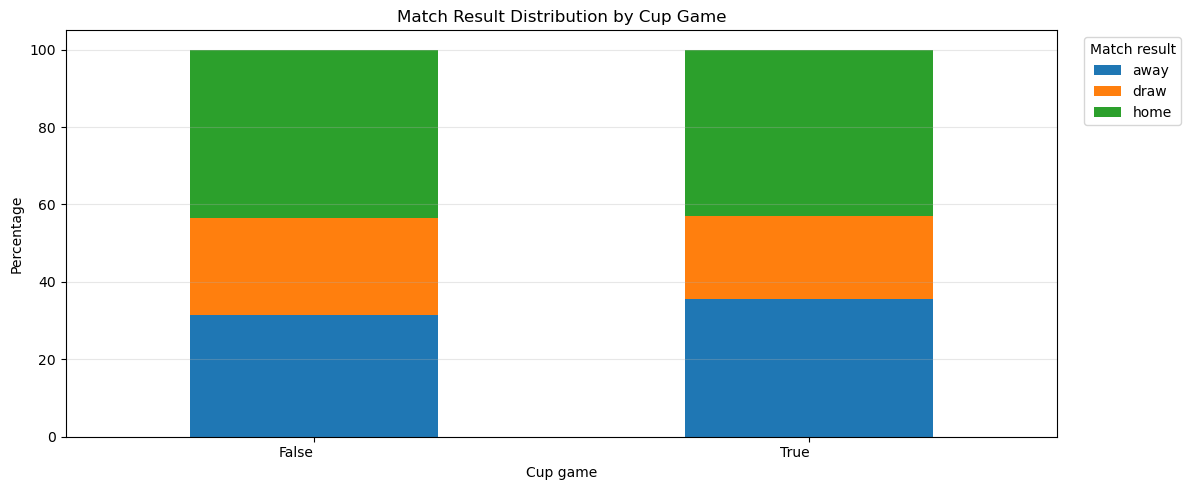

In [26]:
if 'cup_game' in eda_df.columns:
    cup_counts = eda_df['cup_game'].value_counts(dropna=False)
    cup_percentages = eda_df['cup_game'].value_counts(normalize=True,dropna=False).mul(100).round(2)
    
    
    cup_summary = pd.DataFrame({
        'count': cup_counts,
        'percentage': cup_percentages
    })
    
    
    display(cup_summary)
    safe_save_csv(cup_summary.reset_index().rename(columns={'index':'cup_game'}), 'cup_game_distribution.csv',index=False)
    
    cup_target_distribution = crosstab_percentage(eda_df,'cup_game',TARGET_COL)
    
    display(cup_target_distribution)
    safe_save_csv(cup_target_distribution.reset_index(),'cup_game_target_distribution.csv',index=False)
    
    
    plot_stacked_percentage(
        cup_target_distribution,
        title='Match Result Distribution by Cup Game',
        xlabel= 'Cup game',
        filename='06_target_distribution_by_cup_game.png',
        rotation=0
    )
else:
    print('cup_game column does not exist skipp cup game analysis')

,home_matches,percentage
home_club,,
Al Ittihad,91,0.08
River Plate,71,0.06
Rangers,64,0.06
Liverpool,63,0.06
Al Ahli,62,0.06
Juventus,61,0.05
Independiente,60,0.05
Internacional,59,0.05
Olimpia,58,0.05


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\home_club_counts.csv
Saved figure:  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figure\07_top_home_clubs.png


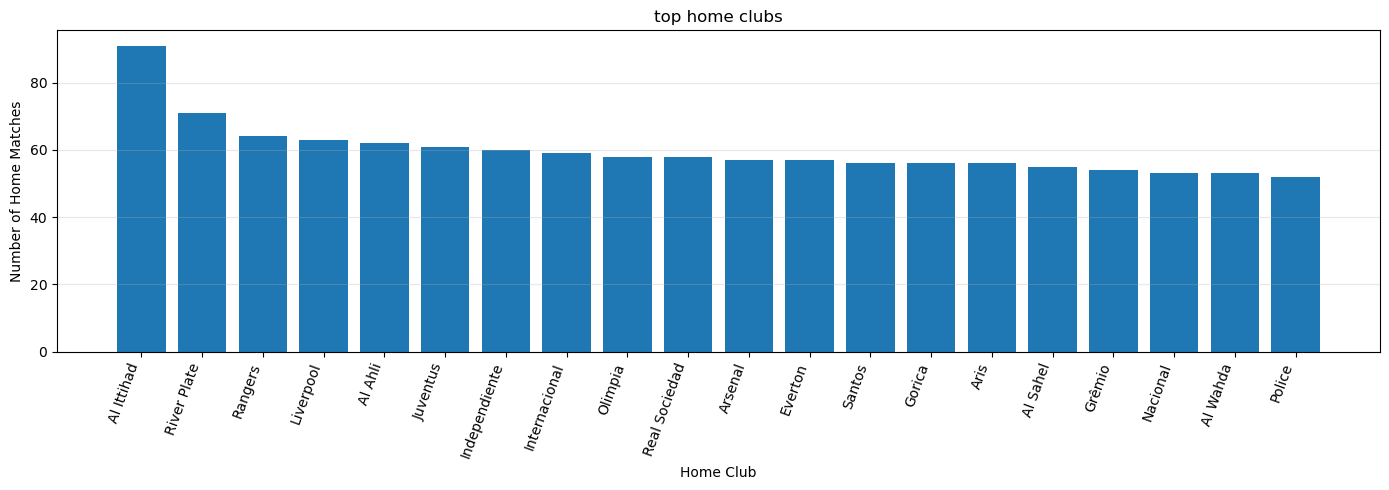

,away_mathces,percentage
away_club,,
Al Ittihad,82,0.07
River Plate,77,0.07
Liverpool,65,0.06
Rangers,64,0.06
Al Ahli,64,0.06
Olimpia,63,0.06
Arsenal,59,0.05
Real Sociedad,58,0.05
Santos,57,0.05


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\away_club_counts.csv
Saved figure:  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figure\08_top_away_clubs.png


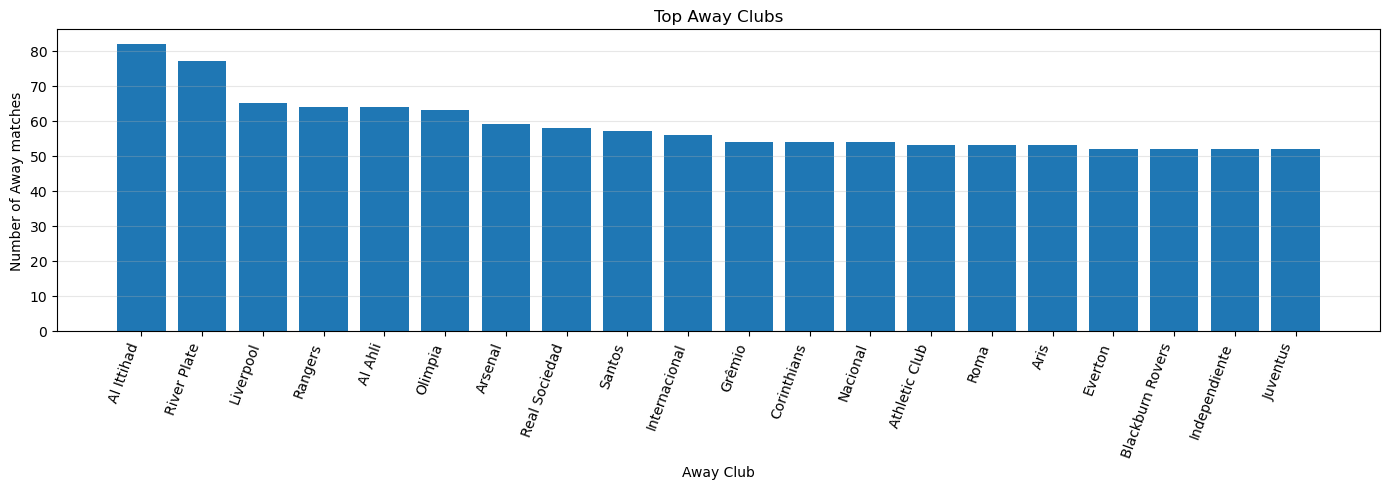

,total_appearances,percentage
Al Ittihad,173,0.08
River Plate,148,0.07
Liverpool,128,0.06
Rangers,128,0.06
Al Ahli,126,0.06
Olimpia,121,0.05
Real Sociedad,116,0.05
Arsenal,116,0.05
Internacional,115,0.05
Juventus,113,0.05


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\combined_club_coverage.csv
Unique clubs: 10215
Clubs with fewer than 5 appearances: 1533
Clubs with fewer than 10 appearances: 3263


In [27]:

if 'home_club' in eda_df.columns:
    home_club_counts = eda_df['home_club'].value_counts(dropna=False)
    
    home_club_summary = pd.DataFrame({
        'home_matches': home_club_counts,
        'percentage': (
            eda_df['home_club']
            .value_counts(normalize=True,dropna=False)
            .mul(100)
            .round(2)
        )
    })
    
    
    display(home_club_summary.head(30))
    
    safe_save_csv(
        home_club_summary.reset_index().rename(columns={'index':'home_club'}),
        'home_club_counts.csv',
        index=False
    )
    
    plot_bar(
        home_club_counts.head(20),
        title = 'top home clubs',
        xlabel='Home Club',
        ylabel= 'Number of Home Matches',
        filename='07_top_home_clubs.png',
        rotation=70,
        figsize=(14,5)
    )
    
else:
    print('home_club column does not exist skip home club analysis')
    
    
if 'away_club' in eda_df.columns:
    away_club_counts = eda_df['away_club'].value_counts(dropna=False)
    
    
    away_club_summary = pd.DataFrame({
        'away_mathces': away_club_counts,
        'percentage': (
            eda_df['away_club']
            .value_counts(normalize=True,dropna=False)
            .mul(100)
            .round(2)
        )
    })
    
    display(away_club_summary.head(30))
    
    safe_save_csv(
        away_club_summary.reset_index().rename(columns={'index':'away_club'}),
        'away_club_counts.csv',
        index=False
    )
    
    
    plot_bar(
        away_club_counts.head(20),
        title= 'Top Away Clubs',
        xlabel=  'Away Club',
        ylabel= 'Number of Away matches',
        filename= '08_top_away_clubs.png',
        rotation=70,
        figsize=(14,5)
    )
else:
    print('away_club columns does not exist skipp away club analysis')
    
    
if 'home_club' in eda_df.columns and 'away_club' in  eda_df.columns:
    combined_clubs =  pd.concat(
        [eda_df['home_club'],eda_df['away_club']],
        axis=0
    )
    
    
    combined_clubs_counts = combined_clubs.value_counts(dropna=False)
    
    
    combined_club_summary = pd.DataFrame({
        'total_appearances': combined_clubs_counts,
        'percentage': (
            combined_clubs.value_counts(normalize=True,dropna=False).mul(100).round(2)
        )
    })
    
    
    display(combined_club_summary.head(30))
    
    combined_club_summary_to_save= (
        combined_club_summary.reset_index().rename(columns={'index':'club'})
    )
    
    
    safe_save_csv(
        combined_club_summary_to_save,
        'combined_club_coverage.csv',
        index=False
    )
    
    rare_clubs_less_5 = int((combined_clubs_counts < 5).sum())
    rare_clubs_less_10 = int((combined_clubs_counts < 10).sum())
    
    print("Unique clubs:", combined_clubs_counts.shape[0])
    print("Clubs with fewer than 5 appearances:", rare_clubs_less_5)
    print("Clubs with fewer than 10 appearances:", rare_clubs_less_10)

else:
    print("home_club and away_club columns are not both available. Skipping combined club analysis.")

,column,missing_count,missing_percentage,dtype,unique_count
169,away_club_recent_manager_id_10,27129,24.45,float64,7936
79,home_club_recent_manager_id_10,26653,24.03,float64,7891
168,away_club_recent_manager_id_9,26150,23.57,float64,8044
78,home_club_recent_manager_id_9,25733,23.20,float64,8002
167,away_club_recent_manager_id_8,25219,22.73,float64,8144
77,home_club_recent_manager_id_8,24869,22.42,float64,8150
166,away_club_recent_manager_id_7,24377,21.97,float64,8303
76,home_club_recent_manager_id_7,23980,21.62,float64,8265
165,away_club_recent_manager_id_6,23525,21.21,float64,8440
75,home_club_recent_manager_id_6,23258,20.96,float64,8385


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\relevant_missing_values.csv
Saved figure:  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figure\09_top_relevant_missing_values.png


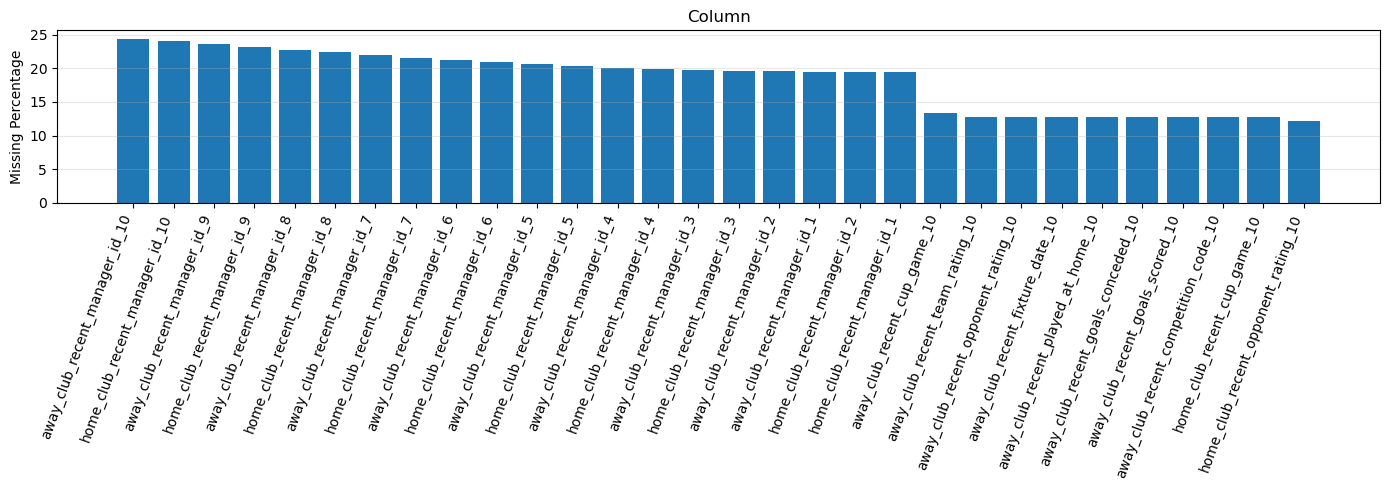

In [28]:
recent_columns_info_eda = recent_pattern_info(eda_df)

recent_cols = recent_columns_info_eda['column'].tolist() if not recent_columns_info_eda.empty else []

relevant_columns = list(dict.fromkeys(existing_column(MAIN_MATCH_COLUMNS,eda_df)+ recent_cols))


relevant_missing_summary = pd.DataFrame({
    'column': relevant_columns,
    'missing_count': [int(eda_df[col].isna().sum()) for col in relevant_columns],
    'missing_percentage' : [round(eda_df[col].isna().mean()*100,2) for col in relevant_columns],
    'dtype': [str(eda_df[col].dtype) for col in relevant_columns],
    'unique_count': [int(eda_df[col].nunique(dropna=True)) for col in relevant_columns]
}).sort_values('missing_percentage',ascending=False)


display(relevant_missing_summary.head(80))
safe_save_csv(relevant_missing_summary,'relevant_missing_values.csv',index=False)


top_missing_relevant = relevant_missing_summary[relevant_missing_summary['missing_count']>0].head(30)


if not top_missing_relevant.empty:
    plot_bar(
        top_missing_relevant.set_index('column')['missing_percentage'],
        title='Column',
        ylabel='Missing Percentage',
        filename= '09_top_relevant_missing_values.png',
        rotation=70,
        figsize=(14,5)
    )
else:
    print('no missing values in relevant columns')

In [29]:

print('number of detected recent-history columns : ', len(recent_columns_info_eda))

display(recent_columns_info_eda.head(30))

safe_save_csv(recent_columns_info_eda,'recent_columns_info_eda.csv',index=False)

if not recent_columns_info_eda.empty:
    recent_feature_availability = (
        recent_columns_info_eda.groupby(['club_side','feature']).agg(
            deteceted_lags = ('recent_number',lambda x: sorted(list(x))),
            deteceted_count = ('recent_number','count'),
            avg_missing_percentage = ('missing_percentage','mean'),
            max_missing_percentage = ('missing_percentage','max'),
            avg_unique_count = ('unique_count','mean')
        )
        .reset_index()
        .sort_values(['club_side','feature'])
    )
    
    
    recent_feature_availability['avg_missing_percentage'] = recent_feature_availability['avg_missing_percentage'].round(2)
    recent_feature_availability['max_missing_percentage'] = recent_feature_availability['max_missing_percentage'].round(2)
    recent_feature_availability['avg_unique_count'] = recent_feature_availability['avg_unique_count'].round(2)
    
    
    display(recent_feature_availability)
    safe_save_csv(recent_feature_availability,'recent_feature_availability.csv',index=False)
    
    
    expected_lags = set(range(1,11))
    
    completeness_rows = []
    
    for (club_side,feature), group in recent_columns_info_eda.groupby(['club_side','feature']):
        deteceted_lags = set(group['recent_number'].tolist())
        
        
        completeness_rows.append({
            'club_side': club_side,
            'feature': feature,
            'deteceted_lag_count': len(deteceted_lags),
            'missing_lags': sorted(list(expected_lags-deteceted_lags)),
            'extra_lags': sorted(list(deteceted_lags-expected_lags)),
            'is_complete_1_to_10': deteceted_lags == expected_lags
        })
        
    recent_completeness  = pd.DataFrame(completeness_rows).sort_values(['club_side','feature'])
    display(recent_completeness)
    safe_save_csv(recent_completeness,'recent_history_completeness.csv',index=False)
    

else:
    print('no recent-history columns found')
    


number of detected recent-history columns :  180


,column,club_side,feature,recent_number,dtype,missing_count,missing_percentage,unique_count
0,home_club_recent_fixture_date_1,home_club,_fixture_date,1,object,1159,1.04,19552
1,home_club_recent_fixture_date_2,home_club,_fixture_date,2,object,2451,2.21,19543
2,home_club_recent_fixture_date_3,home_club,_fixture_date,3,object,3773,3.40,19646
3,home_club_recent_fixture_date_4,home_club,_fixture_date,4,object,5101,4.60,19763
4,home_club_recent_fixture_date_5,home_club,_fixture_date,5,object,6477,5.84,19850
5,home_club_recent_fixture_date_6,home_club,_fixture_date,6,object,7896,7.12,19832
6,home_club_recent_fixture_date_7,home_club,_fixture_date,7,object,9295,8.38,19799
7,home_club_recent_fixture_date_8,home_club,_fixture_date,8,object,10719,9.66,19764
8,home_club_recent_fixture_date_9,home_club,_fixture_date,9,object,12136,10.94,19582
9,home_club_recent_fixture_date_10,home_club,_fixture_date,10,object,13559,12.22,19549


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_columns_info_eda.csv


,club_side,feature,deteceted_lags,deteceted_count,avg_missing_percentage,max_missing_percentage,avg_unique_count
0,away_club,_competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.94,12.81,828.5
1,away_club,_cup_game,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,7.22,13.36,2.0
2,away_club,_fixture_date,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.94,12.81,19651.7
3,away_club,_goals_conceded,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.94,12.81,15.6
4,away_club,_goals_scored,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.94,12.81,16.9
5,away_club,_manager_id,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,21.35,24.45,8485.7
6,away_club,_opponent_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.94,12.82,97015.8
7,away_club,_played_at_home,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.94,12.81,2.0
8,away_club,_team_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.94,12.82,97057.5
9,home_club,_competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,6.54,12.22,831.3


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_feature_availability.csv


,club_side,feature,deteceted_lag_count,missing_lags,extra_lags,is_complete_1_to_10
0,away_club,_competition_code,10,[],[],True
1,away_club,_cup_game,10,[],[],True
2,away_club,_fixture_date,10,[],[],True
3,away_club,_goals_conceded,10,[],[],True
4,away_club,_goals_scored,10,[],[],True
5,away_club,_manager_id,10,[],[],True
6,away_club,_opponent_rating,10,[],[],True
7,away_club,_played_at_home,10,[],[],True
8,away_club,_team_rating,10,[],[],True
9,home_club,_competition_code,10,[],[],True


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_history_completeness.csv


In [30]:

leakage_date_rows =  []

if 'fixture_date_parsed' in eda_df.columns:
    current_dates = eda_df['fixture_date_parsed']
    
    for side in ['home_club','away_club']:
        recent_date_cols = get_recent_columns(side,'fixture_date',numbers=range(1,11),dataframe=eda_df)
        
        
        for col in recent_date_cols:
            recent_dates = pd.to_datetime(eda_df[col],errors='coerce')
            
            valid_mask = current_dates.notna() & recent_dates.notna()
            violation_mask = valid_mask & (recent_dates >= current_dates)
            
            leakage_date_rows.append({
                'column': col,
                'valid_comparisons': int(valid_mask.sum()),
                'violation_percentage': round((violation_mask.sum()/valid_mask.sum()*100),4) if valid_mask.sum() >0 else np.nan,
                'min_recent_date' : recent_dates.min(),
                'max_recent_date' : recent_dates.max()
            })
            
    recent_date_leakage_check  = pd.DataFrame(leakage_date_rows)
    
    display(recent_date_leakage_check )
    
    safe_save_csv(recent_date_leakage_check,'recent_fixture_date_leakage_check.csv',index=False)
    
    total_violations = recent_date_leakage_check['violations_recent_date_not_before_current'].sum() if not recent_date_leakage_check.empty else 0
    
    
    if total_violations > 0:
        print('Warning : Some recent fixture dates are  not  before the current fixture date.')
        print('This must be investigated before modeling')
    else:
        print('no date leakage detected based on recent fixture dates.')

else:
    print('current fixture_date could not be parsed skipped recent leakage check')

""


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_fixture_date_leakage_check.csv
no date leakage detected based on recent fixture dates.


,side,feature,lag,column,non_missing_count,missing_percentage,mean,median,std,min,max,q01,q99
0,home_club,goals_scored,1,home_club_recent_goals_scored_1,109779,1.04,1.343299,1.000000,1.327137,0.000000,18.000000,0.000000,6.000000
1,home_club,goals_scored,2,home_club_recent_goals_scored_2,108487,2.21,1.409966,1.000000,1.350371,0.000000,18.000000,0.000000,6.000000
2,home_club,goals_scored,3,home_club_recent_goals_scored_3,107165,3.40,1.383353,1.000000,1.337314,0.000000,18.000000,0.000000,6.000000
3,home_club,goals_scored,4,home_club_recent_goals_scored_4,105837,4.60,1.401013,1.000000,1.350112,0.000000,21.000000,0.000000,6.000000
4,home_club,goals_scored,5,home_club_recent_goals_scored_5,104461,5.84,1.398139,1.000000,1.341917,0.000000,18.000000,0.000000,6.000000
5,home_club,goals_scored,6,home_club_recent_goals_scored_6,103042,7.12,1.398556,1.000000,1.345225,0.000000,21.000000,0.000000,6.000000
6,home_club,goals_scored,7,home_club_recent_goals_scored_7,101643,8.38,1.398906,1.000000,1.335962,0.000000,15.000000,0.000000,6.000000
7,home_club,goals_scored,8,home_club_recent_goals_scored_8,100219,9.66,1.401840,1.000000,1.335964,0.000000,18.000000,0.000000,6.000000
8,home_club,goals_scored,9,home_club_recent_goals_scored_9,98802,10.94,1.404972,1.000000,1.331830,0.000000,21.000000,0.000000,6.000000
9,home_club,goals_scored,10,home_club_recent_goals_scored_10,97379,12.22,1.402643,1.000000,1.332815,0.000000,18.000000,0.000000,6.000000


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_numeric_stats_by_lag.csv


side,away_club,home_club
lag,,
1,1.432141,1.343299
2,1.367631,1.409966
3,1.397328,1.383353
4,1.382909,1.401013
5,1.390945,1.398139
6,1.393291,1.398556
7,1.395455,1.398906
8,1.393997,1.401840
9,1.393222,1.404972


side,away_club,home_club
lag,,
1,1.323237,1.423569
2,1.393964,1.346908
3,1.358219,1.376224
4,1.374713,1.356501
5,1.359628,1.367209
6,1.364933,1.359057
7,1.362636,1.358736
8,1.359343,1.356399
9,1.361636,1.348252


side,away_club,home_club
lag,,
1,6.786555,6.325486
2,6.460632,6.651585
3,6.590450,6.526625
4,6.520199,6.597575
5,6.573126,6.548819
6,6.536206,6.582106
7,6.549392,6.556376
8,6.535049,6.559520
9,6.530659,6.550602


side,away_club,home_club
lag,,
1,6.281844,6.749435
2,6.604754,6.404746
3,6.452470,6.532907
4,6.512163,6.443774
5,6.451090,6.474777
6,6.462982,6.431073
7,6.430701,6.433476
8,6.418890,6.413614
9,6.408248,6.391937


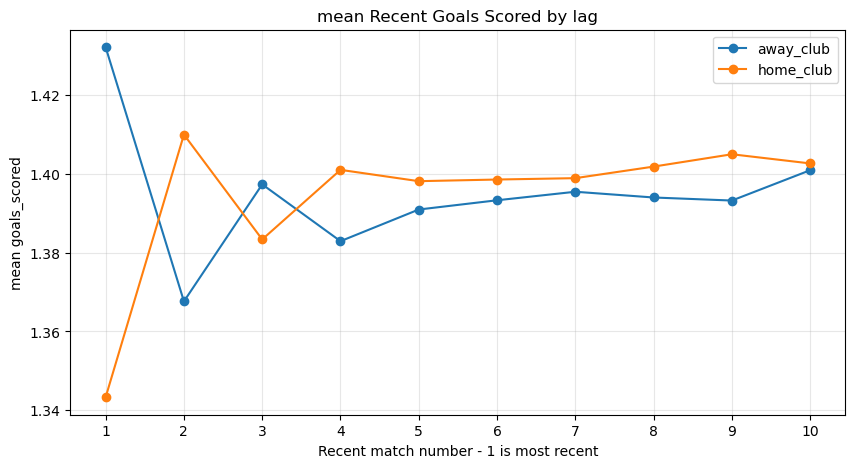

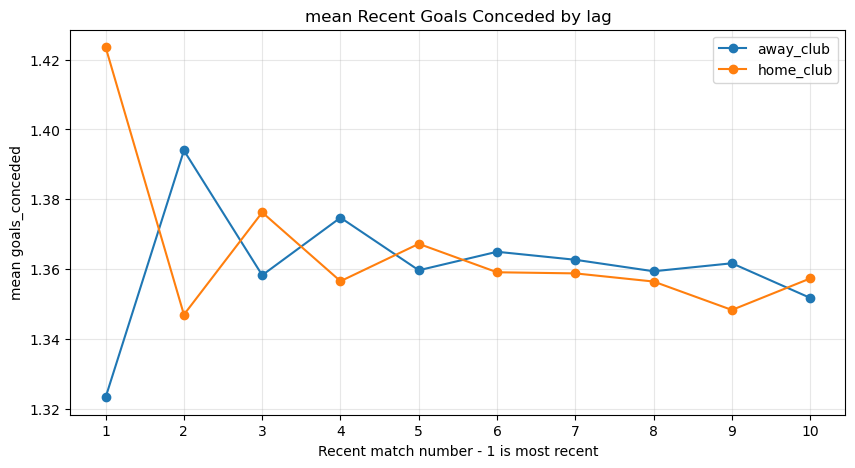

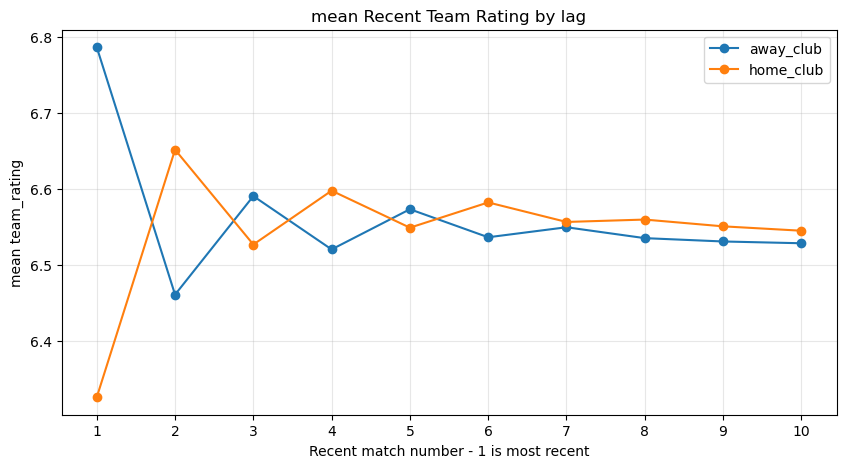

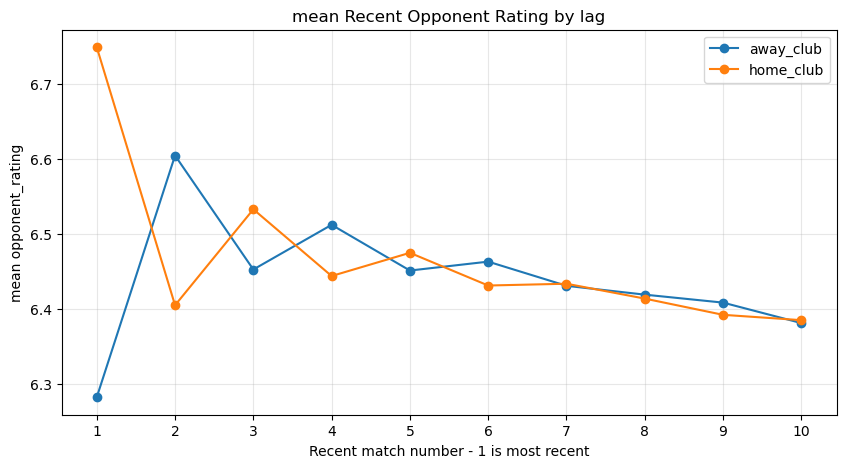

In [31]:
important_recent_numeric_features = [
    'goals_scored',
    'goals_conceded',
    'team_rating',
    'opponent_rating'
]


recent_numeric_stats_rows = []


for side in ['home_club','away_club']:
    for feature in important_recent_numeric_features:
        for lag in range(1,11):
            col = f'{side}_recent_{feature}_{lag}'
            
            
            if col not in eda_df.columns:
                continue
            
            values = to_numeric_series(eda_df[col])
            
            recent_numeric_stats_rows.append({
                'side':side,
                'feature':feature,
                'lag' : lag,
                'column': col,
                'non_missing_count': int(values.notna().sum()),
                'missing_percentage': round(values.isna().mean()*100,2),
                'mean': values.mean(),
                'median': values.median(),
                'std': values.std(),
                'min': values.min(),
                'max': values.max(),
                'q01': values.quantile(0.01),
                'q99': values.quantile(0.99)
            })
            
            
recent_numeric_stats = pd.DataFrame(recent_numeric_stats_rows)

display(recent_numeric_stats.head(50))
safe_save_csv(recent_numeric_stats,'recent_numeric_stats_by_lag.csv',index=False)


for feature in important_recent_numeric_features:
    temp = recent_numeric_stats[recent_numeric_stats['feature'] == feature].copy()
    
    if temp.empty:
        continue
    
    pivot_mean = temp.pivot(index='lag',columns='side',values='mean')
    display(pivot_mean)
    
    plt.figure(figsize=(10,5))
    
    
    for side in pivot_mean.columns:
        plt.plot(pivot_mean.index,pivot_mean[side],marker='o',label=side)
        
        
    plt.title(f'mean Recent {feature.replace('_',' ').title()} by lag')
    plt.xlabel('Recent match number - 1 is most recent')
    plt.ylabel(f'mean {feature}')
    plt.xticks(range(1,11))
    plt.grid(alpha=0.3)
    plt.legend()
    